In [1]:
import sys
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import MODEL_OUTPUT_DIR
from src.train import build_dataset

print("Environment Ready.")

Environment Ready.


In [2]:
print("Loading Validation Dataset...")
# build_dataset() returns (train_ds, val_ds). We only need val_ds for metrics.
_, val_ds = build_dataset()

print("Loading Trained ResNet50 Classifier...")
model_path = MODEL_OUTPUT_DIR / "final_stamp_classifier.keras"
model = tf.keras.models.load_model(model_path)
print("Model Loaded Successfully.")

Loading Validation Dataset...
Found 2400 files belonging to 2 classes.
Using 1920 files for training.
Using 480 files for validation.
Loading Trained ResNet50 Classifier...
Model Loaded Successfully.


In [3]:
y_true = []
y_pred_probs = []

print("Running Inference on Validation Set...")
start_time = time.time()

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(probs)

end_time = time.time()

total_images = len(y_true)
total_time = end_time - start_time
time_per_image = total_time / total_images

# Remember: 0 = forged, 1 = genuine
y_pred = (np.array(y_pred_probs) >= 0.5).astype(int).flatten()

print(f"Processed {total_images} images in {total_time:.2f} seconds.")

Running Inference on Validation Set...
Processed 480 images in 22.18 seconds.


In [5]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("=" * 50)
print("FINAL PERFORMANCE METRICS")
print("=" * 50)
print(f"Classification Accuracy : {accuracy * 100:.2f}%")
print(f"Precision               : {precision * 100:.2f}%")
print(f"Recall                  : {recall * 100:.2f}%")
print(f"F1-Score                : {f1:.4f}")
print(f"Average Inference Speed : {time_per_image * 1000:.2f} ms per stamp")
print("=" * 50)

# Detailed classification report
print("\nDetailed Report:")
print(classification_report(y_true, y_pred, target_names=["Forged", "Genuine"]))

FINAL PERFORMANCE METRICS
Classification Accuracy : 98.54%
Precision               : 99.17%
Recall                  : 97.96%
F1-Score                : 0.9856
Average Inference Speed : 46.21 ms per stamp

Detailed Report:
              precision    recall  f1-score   support

      Forged       0.98      0.99      0.99       235
     Genuine       0.99      0.98      0.99       245

    accuracy                           0.99       480
   macro avg       0.99      0.99      0.99       480
weighted avg       0.99      0.99      0.99       480



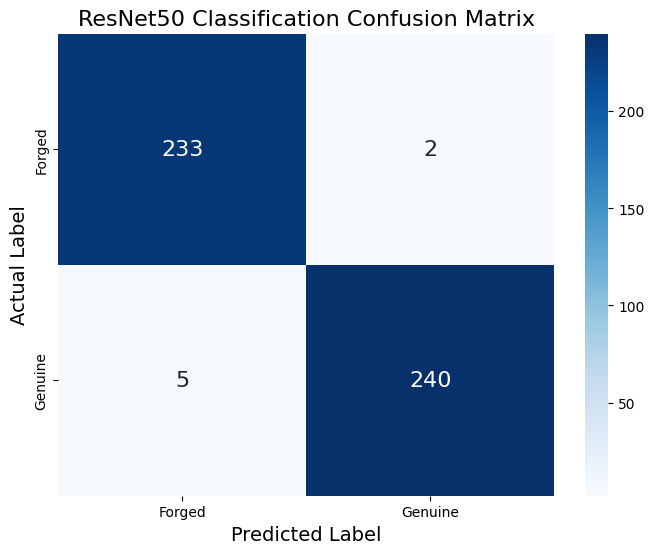

In [6]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Forged", "Genuine"],
    yticklabels=["Forged", "Genuine"],
    annot_kws={"size": 16},
)

plt.title("ResNet50 Classification Confusion Matrix", fontsize=16)
plt.ylabel("Actual Label", fontsize=14)
plt.xlabel("Predicted Label", fontsize=14)
plt.show()